**NOTES**

- CuPy was considered, but due to issues with running on ROCm, was not adopted

- CuDF was also considered, but it's just not worth it for datasets < 10,000 at a minimum. We're working in <900

- Heaviest pre-processing runs in ~20s on Ryzen AI 7 350 (8c 16t) w/ 16gb RAM, so not a computational constraint

- Some loss of data (430 - 1780 cm-1) due to limitations of some spectra (varied measurement ranges)

In [1]:
# 1.0 Imports
from os import listdir, getcwd
from os.path import isfile, join
import csv
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import clone
from scipy.interpolate import interp1d
from scipy.signal import argrelextrema, find_peaks, savgol_filter
from scipy.ndimage import minimum_filter1d
from scipy.integrate import trapezoid

#models
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import VotingClassifier


In [4]:
# 2.0 Functions
def import_paths(res= "High", exo= "7"):
    """

    # Function to batch import filepaths of spectra
    # This is reliant on the specific folder structure:
        >Dir
            >Renamed Data
                >{res} Res
                    >MCF{exo}_U/F_date

    # ---------- #
    res - string, resolution of Raman spectrometer as "High" or "Low"
    exo - string, exosome type used on chip as "7", "10a" or "10aPS"
    # ---------- #
    
    """
    
    root_dir = join(getcwd(), "Renamed Data", f"{res} Res")
    files = [
        join(root_dir, folder, file)
        for folder in listdir(root_dir)
        if folder.startswith(f"MCF{exo}_")
        for file in listdir(join(root_dir, folder))
    ]

    return files

def txtr_to_df(filepath, metad= False):
    """

    # Function to import .txtr files to a dataframe, specifically for the format of the low res Raman spec
    # Each line is delimited by a semicolon (below). 
    # I'm assuming all file formats are the same, or at least header rows. Haven't checked yet, only guaranteed to work on a sample, but it should work
    # use is literally |  df = txtr_to_df(filepath)  |
    # for metadata | df, metadata = txtr_to_df(filepath, metad=True)  |

    # ---------- #
    filepath - string, input filepath
    metad - bool, do you want metadata returned as a secondary output. Not sure what you'd use it for besides laser power, but worth having the whole thing.
    # ---------- #

    """
    
    metadata = {}
    data_start = None
    with open(filepath, 'r') as f:
        lines = f.readlines()
    for i, line in enumerate(lines):
        line = line.strip()
        if line.startswith("Pixel;"):
            data_start = i
            break
        if ";" in line:
            key, _, value = line.partition(";")
            metadata[key.strip()] = value.strip()
    df = pd.read_csv(filepath, sep=";", skiprows=data_start)
    df = df.dropna(axis=1)
    df.columns = df.columns.str.strip()
    df = df[["Raman Shift", "Dark Subtracted #1"]].copy()
    df.columns = ["Raman Shift", "Intensity"]
    df = df[df["Raman Shift"] >= 400]
    df = df[df["Raman Shift"] <= 1800].reset_index(drop= True)
    df["Index"] = np.arange(len(df))

    if metad:
        return df, metadata
    else:
        return df

def txt_to_df(filepath, delimiter= "\\t"):
    """

    # Function to import .txtfiles to a dataframe, specific for format of high res Raman spec
    # Discards headers and manually defines them.
    # Specific to high res, not functionalising for anything else
    # There is no metadata to scrape

    # ---------- #
    filepath - string input filepath
    delimiter - string input in-line delimiter for .txt file (multicolumn)
    # ---------- #


    """
    
    df = pd.read_csv(filepath, sep=delimiter, header= None, engine= "python")
    df = df.dropna(axis=1)
    cols =  ["Raman Shift", "Intensity"]
    df.columns = cols
    df["Index"] = np.arange(len(df))

    return df

def batch_import(res= "High", exo= "7"):
    """

    # Function to batch import files, essentially master function for this section
    # Calls the 3 above functions. Might be worth just defining them internally instead, but the txt(r) imports might be useful outside

    # ---------- #
    res - string, as in import_paths()
    exo - string, as in import_paths()
    # ---------- #
    
    """
    filenames = import_paths(res, exo)
    if res == "Low":
        dfs = [txtr_to_df(file) for file in filenames]
    elif res == "High":
        dfs = [txt_to_df(file) for file in filenames]
    else:
        raise ValueError(f"Mode was set to {mode}\nThis is not a supported filetype")

    return dfs

def baseline_minmax(df, n_splits= 10, trough_mode= 0, trough_param_mode = 0):
    """

    # Baseline correction and minmax normalisation to 0 - 1
    # I know it's not versatile, I don't particularly care

    # ---------- #
    df - pandas dataframe, your dataframe after data correction (above)
    n_splits - int, number of splits for baseline (1/%dataframe per split)
    trough_mode - int:
        0 - argrelextrema - derivative based. standard approach for general signal processing
        1 - thresholded minima - local minima, minimum prominence and minimum distance between minima to threshold
        2 - percentile based minima. NOT RECOMMENDED for this type - good for flat plots, curved will break
        3 - morphological - erosion using min filter
        4 - argrelextrema with savitzky-golay smoothing
    trough_params (wip) - pass parameters like prominence, window_length etc. NOT IN USE
    # ---------- #

    """
    
    trough_dict = {
        # Dummy Argrel
        "Argrel": [
            [0],
            [0]
        ],
    
        "Threshold": [
            [0.05, 10],
            [0.15, 20]
        ],

        "Percentile": [
            [5],
            [5]
        ],
    
        "Morpho": [
            [10],
            [20]
        ],
    
        "Argrel_SavGol": [
            [6, 3],
            [60, 9]
        ]
    }
    
    troughs = None
    shift = df.set_index("Index")["Raman Shift"]
    intensity = df.set_index("Index")["Intensity"]
    
    if trough_mode == 0:
        trough_params= trough_dict["Argrel"][trough_param_mode]
        troughs = argrelextrema(intensity.values, np.less)[0]
    elif trough_mode == 1:
        trough_params= trough_dict["Threshold"][trough_param_mode]
        troughs, props = find_peaks(-intensity.values, prominence=trough_params[0], distance=trough_params[1])
    elif trough_mode == 2:
        trough_params= trough_dict["Percentile"][trough_param_mode]
        threshold = np.percentile(intensity.values, trough_params[0])
        troughs = np.where(intensity.values <= threshold)[0]
    elif trough_mode == 3:
        trough_params= trough_dict["Morpho"][trough_param_mode]
        baseline_candidate = minimum_filter1d(intensity.values, size=trough_params[0])
        troughs = np.where(intensity.values == baseline_candidate)[0]
    elif trough_mode == 4:
        trough_params= trough_dict["Argrel_SavGol"][trough_param_mode]
        intensity_smooth = savgol_filter(intensity.values, window_length=trough_params[0], polyorder=trough_params[1])
        troughs = argrelextrema(intensity_smooth, np.less)[0]
    else:
        raise ValueError(f"Invalid trough_mode {trough_mode}.")

    splits = np.array_split(troughs, n_splits)
    baselines = [s.min() for s in splits]
    baselines.append(troughs[-1])
    X_curve = shift.loc[baselines].values
    Y_curve = intensity.loc[baselines].values
    X_troughs = shift.loc[troughs].values
    Y_troughs = intensity.loc[troughs].values
    curve = interp1d(X_curve, Y_curve, kind='linear', fill_value='extrapolate')
    baseline_at_troughs = curve(X_troughs)
    uncorrected = Y_troughs - baseline_at_troughs
    corrected = np.clip(uncorrected, 0, None)
    normalised = MinMaxScaler().fit_transform(np.array(np.array(corrected).reshape(-1, 1))).flatten()

    return X_troughs, normalised

def all_preprocesses_batch(dfs, res= "High"):
    """

    # Returns a list:
        >per preprocessing technique
            >per df
                >X values
                >Y values

    # ---------- #
    dfs - list, containing pandas dataframes structured ["Raman Shift", "Intensity", "Index"]
    res - string, resolution of spectrometer used for dataset
    # ---------- #
    
    """
    if res == "High":
        extracted = [[baseline_minmax(df, n_splits= 20, trough_mode= i, trough_param_mode= 1) for df in dfs] for i in range(0, 5)]
    elif res == "Low":
        extracted = [[baseline_minmax(df, n_splits= 20, trough_mode= 0, trough_param_mode= 0) for df in dfs] for i in range(0, 5)]
    else:
        raise ValueError(f"res was set to {res}\nThis is not a supported resolution.\nChoose either High or Low")

    return extracted

def extreme_outlier_removal(dataset, max_thresh, min_thresh):
    """

    # Identifies outliers outside a specific threshold (otherwise interpolate_at_x() breaks)
    # Basically error management. There are like 4 spectra that are off by about 50 cm-1 somehow

    # ---------- #
    dataset - array, all_preprocesses[x][y]
    max_thresh - int, maximum threshold
    min_thresh - int, minimum theshold
    # ---------- #
    
    """

    keep = []
    kept_indices = []
    for idx, i in enumerate(dataset):
        x = i[0]
        if x.max() >= max_thresh and x.min() <= min_thresh:
            keep.append(i)
            kept_indices.append(idx)
        else:
            print(f"Outlier detected and removed: max={x.max()}, min={x.min()}")
    return keep, kept_indices

def interpolate_at_x(x, y, x_target):
    """

    # Mathematical function to identify intersection of x-value with plot of points either side of it
    # Outputs intersection, target

    # ---------- #
    x - array, x-values
    y - array, y-values
    x_target - int, target value
    # ---------- #
    
    """
    sort_idx = np.argsort(x)
    x = x[sort_idx]
    y = y[sort_idx]
    idx = np.searchsorted(x, x_target)
    if idx == 0 or idx == len(x):
        raise ValueError("Target x-value is outside data range.")
    x1, y1 = x[idx-1], y[idx-1]
    x2, y2 = x[idx], y[idx]

    return y1 + (y2 - y1) * ((x_target - x1) / (x2 - x1)), x_target

def batch_interpolate_at_x(x, y, x_targets):
    """

    # Runs interpolate_at_x over an array
    # Outputs interpolate_at_x as a list

    # ---------- #
    x - array, x-values
    y - array, y-values
    x_targets - array, indexes for interpolation
    # ---------- #
    
    """
    
    intersections = [interpolate_at_x(x, y, target) for target in x_targets]
    return intersections


def find_area(x, y, intersections):
    """

    # Finds the area of a range over a single dataset (below, generate_auc_df)
    # Outputs a list, containing [0] left bound [1] right bound [2] area

    # ---------- #
    x - array, x-values
    y - array, y-values
    x_targets - array, output of batch_interpolate_at_x
    # ---------- #
    
    """
    
    outputs = []
    for i in range(len(intersections)):
        left_lim = intersections[i][1]
        left_value = intersections[i][0]
        try:
            right_lim = intersections[i+1][1]
            right_value = intersections[i+1][0]
        except:
            ValueError()
        if right_lim != left_lim:
            mask = (x > left_lim) & (x < right_lim)
            x_vals = np.concatenate((
                [left_lim],
                x[mask],
                [right_lim]
            ))
            y_vals = np.concatenate((
                [left_value],
                y[mask],
                [right_value]
            ))
            outputs.append([left_lim, right_lim, trapezoid(y_vals, x_vals)])

    return outputs

def generate_auc_df(dataset, range_width= 5, class_col= True, class_val = 1):
    """

    # Generates a dataframe, based on interpolate_at_x, batch_interpolate_at_x and find_area that is explicitly labeled
    # Outputs a single row dataframe
    # Range reduced to 430 - 1780 due to differences in wavenumber in different datasets.

    # ---------- #
    dataset - array, "Layer 4" index of all_preprocesses in __main__
    range_width - int, width of a "band", best as a multiple of 5, I didn't add error management
    class_col - bool, if yes adds a column "Class"
    class_val - int, the value in class_col
    # ---------- #
    
    """
    
    x = dataset[0]
    y = dataset[1]
    intersections = batch_interpolate_at_x(x, y, np.arange(430, 1780, range_width))
    data = find_area(x, y, intersections)
    frame = pd.DataFrame([[i[-1] for i in data]], columns=[f"{i[0]} - {i[1]}" for i in data])
    if class_col:
        frame["Class"] = class_val

    return frame

def batch_auc_df(dataset, range_width= 5, class_col= True, class_val= 1, file_ids= None):
    """

    # Runs generate_auc_df() over a series of files (per-res&exo combo)
    # Outputs a dataframe of all returns, with class column if used.

    # ---------- #
    dataset - array, all_preprocesses[x][x]
    range_width - as in generate_auc_df()
    class_col - as in generate_auc_df()
    class_val - as in generate_auc_df()
    # ---------- #
    
    """
    
    individual_dfs = [generate_auc_df(i, range_width, class_col, class_val) for i in dataset]
    df = pd.concat(individual_dfs).reset_index(drop=True)
    if file_ids is not None:
        df["file_id"] = file_ids
    return df

def split_data(df, training_size=0.7, random_state=42):
    """
    
    # Stratified 70/15/15 (adjustable) train/test/val split. test/val is always 50/50 of remainder
    # Stratification ensures class balance is preserved across all splits. (slight imbalance in main)
    # Outputs train, test, val / x,y in that order

    # ---------- #
    df - pandas dataframe, entire dataset post-processing
    training_size - float, decimal ratio of dataset as training set
    random_state - random state param for train_test_split, ensures same splits created each time
    # ---------- #
    
    """
    y = df["Class"].values
    X = df.drop(columns=["Class"]).values

    X_train, X_temp, y_train, y_temp = train_test_split(
        X, y,
        test_size=(1 - training_size),
        random_state=random_state,
        stratify=y
    )
    X_test, X_val, y_test, y_val = train_test_split(
        X_temp, y_temp,
        test_size=0.5,
        random_state=random_state,
        stratify=y_temp
    )
    return X_train, y_train, X_test, y_test, X_val, y_val

def split_data_with_source(df, training_size=0.7, random_state=42):
    feature_names = [c for c in df.columns if c not in ["Class", "source", "file_id"]]
    y = df["Class"].values
    source = df["source"].values
    file_id = df["file_id"].values
    X = df.drop(columns=["Class", "source", "file_id"]).values

    X_train, X_temp, y_train, y_temp, s_train, s_temp, f_train, f_temp = train_test_split(
        X, y, source, file_id,
        test_size=(1 - training_size),
        random_state=random_state,
        stratify=y
    )
    X_test, X_val, y_test, y_val, s_test, s_val, f_test, f_val = train_test_split(
        X_temp, y_temp, s_temp, f_temp,
        test_size=0.5,
        random_state=random_state,
        stratify=y_temp
    )
    return X_train, y_train, X_test, y_test, X_val, y_val, s_test, s_val, f_test, f_val, feature_names

def verify_splits(splits):
    """

    # Checks if splits are stratified properly.
    # Prints all outputs, just call.

    # ---------- #
    splits - list, splits
    # ---------- #
    
    """
    print("% Negative Across Splits")
    print(f"Train:      {(splits[1] == 0).mean():.1%}")
    print(f"Test:       {(splits[3] == 0).mean():.1%}")
    print(f"Val:        {(splits[5] == 0).mean():.1%}")
    neg = (splits[1] == 0).sum()
    pos = (splits[1] == 1).sum()
    scale_pos_weight = neg / pos
    print(f"Negative (training):   {neg}")
    print(f"Positive (training):   {pos}")
    print(f"scale_pos_weight for XGBoostClassifier: {scale_pos_weight:.4f}")
    if scale_pos_weight > 0.8 and scale_pos_weight < 1.2:
        print("This may not be a significant value (0.4-0.6 ratio)")

def compute_metrics(y_true, y_pred):
    """

    # Computes metrics for a sample (test/val)
    # Returns list of scores

    # ---------- #
    y_true - numpy array, true values
    y_pred - numpy array, predicted values
    # ---------- #
    
    """
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]

def basic_model_test(splits, print_it=True):
    """

    # All-in-one to generate basic metrics for all 7 untuned models, for retrospective comparison with tuned models.
    # Takes splits (same as everything else) as input
    # Returns models, metrics for testing set, metrics for validation set
    # I know we don't need to run this for val and test, but theres literally no reason not to (ctd.)
    # these are still unseen data to main model, and using a larger sample test would skew results (ctd.)
    # this instead gives us two sets to compare it to for increased robustness.

    # ---------- #
    splits - list, split data
    print_it - bool, prints outputs to files ("Untuned_x" files)
    # ---------- #

    """
    
    models = [
        DecisionTreeClassifier(random_state= 42, class_weight= "balanced"),
        RandomForestClassifier(bootstrap= True, n_jobs= -1, random_state= 42, class_weight= "balanced"),
        KNeighborsClassifier(algorithm= "auto", n_jobs= -1),
        LGBMClassifier(n_jobs= -1, class_weight= "balanced"),
        XGBClassifier(booster= "gbtree", n_jobs= -1, random_state= 42, tree_method= "hist", eval_metric= "logloss", objective="binary:logistic"),
        AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight="balanced"), random_state= 42),
        SVC(random_state= 42, class_weight= "balanced", probability= True)
    ]

    for model in models:
        model.fit(splits[0], splits[1])

    pred_test = [m.predict(splits[2]) for m in models]
    pred_val  = [m.predict(splits[4]) for m in models]
    confm_test = [confusion_matrix(splits[3], p) for p in pred_test]
    confm_val  = [confusion_matrix(splits[5], p) for p in pred_val]

    metrics_test = [compute_metrics(splits[3], p) for p in pred_test]
    metrics_val  = [compute_metrics(splits[5], p) for p in pred_val]

    metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
    fig1, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig1.suptitle("Untuned Model Metrics")
    for ax, metrics, title in zip(axes,
                                   [metrics_test, metrics_val],
                                   ["Test Set", "Validation Set"]):
        for j, label in enumerate(metric_labels):
            ax.scatter(np.arange(len(model_names)), [m[j] for m in metrics], label=label, marker=".")
        ax.set_xticks(np.arange(len(model_names)))
        ax.set_xticklabels(model_names, rotation=45, ha="right")
        ax.set_ylim(0, 1)
        ax.set_title(title)
        ax.legend()
    fig1.tight_layout()
    if print_it:
        fig1.savefig("Plots\\Untuned_Metrics.png", dpi=150, bbox_inches="tight")
    plt.close(fig1)

    tick_labels = ["Positive", "Negative"]
    fig2, ax = plt.subplots(len(model_names), 2, figsize=(10, 5 * len(model_names)))
    fig2.suptitle("Untuned Model Confusion Matrices")
    fig2.supxlabel("Predicted Values")
    fig2.supylabel("True Values")
    for i, (cm1, cm2, name) in enumerate(zip(confm_test, confm_val, model_names)):
        for j, (cm, cmap, split) in enumerate(zip([cm1, cm2], ["Reds", "Purples"], ["Test", "Validation"])):
            ax[i, j].imshow(cm, cmap=cmap)
            ax[i, j].set_title(f"{name} — {split}")
            ax[i, j].set_xticks(range(2))
            ax[i, j].set_xticklabels(tick_labels, rotation=45, ha="right")
            ax[i, j].set_yticks(range(2))
            ax[i, j].set_yticklabels(tick_labels)
            for r in range(2):
                for c in range(2):
                    ax[i, j].text(c, r, cm[r, c], ha="center", va="center", color="black")
    fig2.tight_layout(rect=[0, 0, 1, 0.975])
    if print_it:
        fig2.savefig("Plots\\Untuned_Confusion_Matrices.png", dpi=150, bbox_inches="tight")
    plt.close(fig2)

    lines = ["Untuned Model Metrics\n" + "=" * 40]
    for name, mt, mv in zip(model_names, metrics_test, metrics_val):
        lines.append(f"\n{name}")
        lines.append(f"  Test  | Acc: {mt[0]:.3f} | Prec: {mt[1]:.3f} | Rec: {mt[2]:.3f} | F1: {mt[3]:.3f}")
        lines.append(f"  Val   | Acc: {mv[0]:.3f} | Prec: {mv[1]:.3f} | Rec: {mv[2]:.3f} | F1: {mv[3]:.3f}")
    output = "\n".join(lines)
    if print_it:
        with open("Texts\\Untuned_Metrics.txt", "w") as f:
            f.write(output)

    return models, metrics_test, metrics_val

def cross_validated_parameter_tuning(X_train, y_train, model_dict, folds= 5, to_file= False, file_name= "default_parameter_tuning.csv", print_status= True):
    """
    
    # Takes training data as input, runs 5-fold (variable) parameter search for best params.
    # Returns list of best params, scores, model and model name.
    # model_dict structure:
        >model_dict (dict)
            >model_name (dict)
                >model (class)
                >paramgrid (dict)
                    >parameter (list)
    
    # ---------- #
    X_train - numpy array, training data
    y_train - numpy array, classes
    model_dict - dict, models and parameters
    to_file - bool, print to file, yes or no
    # ---------- #
    
    """
    params_per_model = []
    for mod in model_dict:
        if print_status:
            print(f"Tuning for {mod}")
        model = model_dict[mod]["Model"]
        param_grid = model_dict[mod]["ParamGrid"]
        if len(param_grid) > 6:
            clf = RandomizedSearchCV(model, param_grid, n_jobs= -1, scoring= "roc_auc", n_iter= 500, cv= folds)
        else:
            clf = GridSearchCV(model, param_grid, n_jobs= -1, scoring= "roc_auc", cv= folds)
        clf.fit(X_train, y_train)
        best_params = clf.best_params_
        best_score = clf.best_score_
        best_model = clf.best_estimator_
        params_per_model.append([mod, best_params, best_score, best_model])
        if print_status:
            print(f"Tuning Finished for {mod}", "\n")
    if to_file:
        with open(file_name, 'w', newline='') as file:
            writer = csv.writer(file)
            writer.writerows(params_per_model)
    return params_per_model

def fit_tuned_models(X_train, y_train, model_dict, print_it= True):
    """
    
    # Takes training data as input, fits each model using tuned hyperparameters.
    # Returns list of trained models.
    # Cloning is cool, ensures no refitting when calling model directly from dict.
    
    # ---------- #
    X_train - numpy array, training data
    y_train - numpy array, classes
    model_dict - dict, models and parameters
    print_it - bool, print status if true
    # ---------- #
    
    """
    models = []
    for mod in model_dict:
        if print_it:
            print(f"Training for {mod}")
        clf = clone(model_dict[mod]["Model"])
        params = model_dict[mod]["TunedParams"]
        clf.set_params(**params)
        clf.fit(X_train, y_train)
        models.append(clf)
        if print_it:
            print(f"Training Finished for {mod}", "\n")
    return models

def select_threshold(model, splits, model_name= "Model", to_file= True, n_thresholds= 200, balance_tolerance= 0.15):
    """

    # Confidence thresholding to find the best F1 score with val set, with a mandatory x% (balance_tolerance) max variance between precision and recall.
    # Takes splits and model input, extracts val set, tunes thresholds.
    # Returns identified thresholds, and prints scores to .txt files, plots to .png files.
    
    # ---------- #
    model - class, fitted classifier with predict_proba()
    splits - list of numpy arrays
    model_name - str, used in plot titles and filenames
    to_file - bool, save plot and txt output to file
    n_thresholds - int, number of thresholds to sweep
    balance_tolerance - float, max% variance between precision and recall (avoids tuning to 100% precision or 100% recall models)
    # ---------- #
    
    """
    
    X_val = splits[4]
    y_val = splits[5]
    
    proba = model.predict_proba(X_val)[:, 1]
    thresholds = np.linspace(0, 1, n_thresholds)

    f1_scores = []
    prec_scores = []
    rec_scores = []

    for t in thresholds:
        preds = (proba >= t).astype(int)
        f1_scores.append(f1_score(y_val, preds, zero_division=0))
        prec_scores.append(precision_score(y_val, preds, zero_division=0))
        rec_scores.append(recall_score(y_val, preds, zero_division=0))

    best_idx = np.argmax(f1_scores)

    prec = np.array(prec_scores)
    rec = np.array(rec_scores)
    f1 = np.array(f1_scores)
    
    imbalance = np.abs(prec - rec)
    balanced_mask = imbalance <= balance_tolerance
    
    if not balanced_mask[best_idx]:
        balanced_f1 = np.where(balanced_mask, f1, 0)
        best_idx = np.argmax(balanced_f1)

    best_threshold = thresholds[best_idx]
    best_f1 = f1_scores[best_idx]

    fig, ax = plt.subplots(figsize=(10, 5))
    ax.plot(thresholds, f1_scores, label="F1", linewidth=2)
    ax.plot(thresholds, prec_scores, label="Precision", linestyle="--")
    ax.plot(thresholds, rec_scores, label="Recall", linestyle="--")
    ax.axvline(best_threshold, color="red", linestyle=":", label=f"Best threshold = {best_threshold:.3f}")
    ax.set_xlabel("Threshold")
    ax.set_ylabel("Score")
    ax.set_title(f"Threshold Selection: {model_name}")
    ax.set_ylim(0, 1)
    ax.legend()
    fig.tight_layout()

    if to_file:
        fig.savefig(f"Plots\\Threshold_{model_name}.png", dpi=150, bbox_inches="tight")
    plt.close(fig)

    lines = [
        f"Threshold Selection: {model_name}",
        "=" * 40,
        f"  Best Threshold : {best_threshold:.4f}",
        f"  Best F1        : {best_f1:.4f}",
        f"  Precision @ t  : {prec_scores[best_idx]:.4f}",
        f"  Recall @ t     : {rec_scores[best_idx]:.4f}",
    ]
    output = "\n".join(lines)
    if to_file:
        with open(f"Texts\\Threshold_{model_name}.txt", "w") as f:
            f.write(output)

    return best_threshold, best_f1


def select_all_thresholds(models, model_names, splits, to_file= True):
    """
    
    # Runs select_threshold() across all models.
    # Returns list of threshold values for all models'

    # ---------- #
    models - list, trained models with tuned hyperparameters
    model_names - list, names of models in order
    splits - list of numpy arrays, train/test/val split
    to_file - bool, print values
    # ---------- #

    """
    
    thresholds = {}
    for model, name in zip(models, model_names):
        t, f1 = select_threshold(model, splits, model_name= name, to_file= to_file)
        thresholds[name] = t
    return thresholds

def predict_with_threshold(model, X, threshold):
    """

    # Wrapper func, makes models predict using threshold instead of normal 0.5 confidence.
    # Returns same output as model.predict(X) - boolean 1/0

    # ---------- #
    model - class, trained model
    X - numpy array, X data (train test or val, works for any)
    threshold - float, the new threshold to use
    # ---------- #
    
    """
    
    proba = model.predict_proba(X)[:, 1]
    return (proba >= threshold).astype(int)
    
def bulk_predict_with_threshold(models, model_names, X, thresholds):
    """
    
    # Runs predict_with_threshold for all models in batch.
    # Returns list of prediction arrays in same order as models/model_names.
    
    # ---------- #
    models - list, fitted classifiers
    model_names - list, model name strings matching thresholds keys
    X - numpy array, feature data
    thresholds - dict, {model_name: threshold}
    # ---------- #
    
    """
    
    preds = []
    for model, name in zip(models, model_names):
        preds.append(predict_with_threshold(model, X, thresholds[name]))

    return preds
    
def tuned_outputs(models, model_names, splits, thresholds, to_file=True):
    """
    
    # Generates output plots and metrics for tuned models with applied thresholds.
    # Metrics and predictions computed internally from tuned models and thresholds.
    # Gives validation metrics too, even though they are unused. Should demonstrate skew (better performance on val).
    
    # ---------- #
    models - list, fitted tuned models
    model_names - list, model name strings
    splits - list, split data
    thresholds - dict, {model_name: threshold}
    print_it - bool, saves outputs to files
    # ---------- #
    
    """

    pred_test = bulk_predict_with_threshold(models, model_names, splits[2], thresholds)
    pred_val  = bulk_predict_with_threshold(models, model_names, splits[4], thresholds)

    confm_test = [confusion_matrix(splits[3], p) for p in pred_test]
    confm_val  = [confusion_matrix(splits[5], p) for p in pred_val]

    metrics_test = [compute_metrics(splits[3], p) for p in pred_test]
    metrics_val  = [compute_metrics(splits[5], p) for p in pred_val]

    metric_labels = ["Accuracy", "Precision", "Recall", "F1-Score"]
    fig1, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig1.suptitle("Tuned Model Metrics")
    for ax, metrics, title in zip(axes,
                                   [metrics_test, metrics_val],
                                   ["Test Set", "Validation Set"]):
        for j, label in enumerate(metric_labels):
            ax.scatter(np.arange(len(model_names)), [m[j] for m in metrics], label=label, marker=".")
        ax.set_xticks(np.arange(len(model_names)))
        ax.set_xticklabels(model_names, rotation=45, ha="right")
        ax.set_ylim(0, 1)
        ax.set_title(title)
        ax.legend()
    fig1.tight_layout()
    if to_file:
        fig1.savefig("Plots\\Tuned_Metrics.png", dpi=150, bbox_inches="tight")
    plt.close(fig1)

    tick_labels = ["Positive", "Negative"]
    fig2, ax = plt.subplots(len(model_names), 2, figsize=(10, 5 * len(model_names)))
    fig2.suptitle("Tuned Model Confusion Matrices")
    fig2.supxlabel("Predicted Values")
    fig2.supylabel("True Values")
    for i, (cm1, cm2, name) in enumerate(zip(confm_test, confm_val, model_names)):
        for j, (cm, cmap, split) in enumerate(zip([cm1, cm2], ["Reds", "Purples"], ["Test", "Validation"])):
            ax[i, j].imshow(cm, cmap=cmap)
            ax[i, j].set_title(f"{name} — {split}")
            ax[i, j].set_xticks(range(2))
            ax[i, j].set_xticklabels(tick_labels, rotation=45, ha="right")
            ax[i, j].set_yticks(range(2))
            ax[i, j].set_yticklabels(tick_labels)
            for r in range(2):
                for c in range(2):
                    ax[i, j].text(c, r, cm[r, c], ha="center", va="center", color="black")
    fig2.tight_layout(rect=[0, 0, 1, 0.975])
    if to_file:
        fig2.savefig("Plots\\Tuned_Confusion_Matrices.png", dpi=150, bbox_inches="tight")
    plt.close(fig2)

    lines = ["Tuned Model Metrics\n" + "=" * 40]
    for name, mt, mv in zip(model_names, metrics_test, metrics_val):
        lines.append(f"\n{name} (threshold: {thresholds[name]:.4f})")
        lines.append(f"  Test  | Acc: {mt[0]:.3f} | Prec: {mt[1]:.3f} | Rec: {mt[2]:.3f} | F1: {mt[3]:.3f}")
        lines.append(f"  Val   | Acc: {mv[0]:.3f} | Prec: {mv[1]:.3f} | Rec: {mv[2]:.3f} | F1: {mv[3]:.3f}")
    output = "\n".join(lines)
    if to_file:
        with open("Texts\\Tuned_Metrics.txt", "w") as f:
            f.write(output)

    return metrics_test, metrics_val

def generate_top_mods_ensemble(eval_metrics, model_names, model_dict, splits, thresholds, n_models= 3, print_it= True):
    """

    # Generates soft-voting ensemble classifier (hard voting does not allow for custom thresholding) based on top-x (n_models) models by ROC_AUC.
    # Returns model, threshold, sub-model names

    # ---------- #
    eval_metrics - list, ROC_AUC scores from CV param tuning
    model_names - list, model names
    model_dict - dict, same as every other call
    splits - list of numpy arrays, same as every other call
    thresholds - list, thresholds per model
    n_models - int, top X models to include in ensemble
    print_it - bool, print outputs if True
    # ---------- #
    
    """
    
    top_mods = sorted(zip(eval_metrics, model_names), reverse= True)[:n_models]
    if print_it:
        print(f"Top {n_models} Models by AUC_ROC Scoring in Cross-Validated Hyperparameter Tuning:")
        best_mods = [mod[1] for mod in top_mods]
        for mod in best_mods:
            print(mod)
    top_mods_names = [name for score, name in top_mods]
    estimators = [(name, clone(model_dict[name]["Model"])) for name in top_mods_names]
    for name, clf in estimators:
        clf.set_params(**model_dict[name]["TunedParams"])
    clf_ensemble = VotingClassifier(estimators, voting="soft", n_jobs=-1)
    clf_ensemble.fit(splits[0], splits[1])
    ensemble_threshold = np.mean([thresholds[name] for name in top_mods_names])
    if print_it:
        print("\nEnsemble Classifier Generated from:")
        for mod in best_mods:
            print(mod)
        print(f"Ensemble Threshold: {ensemble_threshold:.4f}\n")

    return clf_ensemble, ensemble_threshold

def find_misclassified(models, model_names, splits, thresholds, source_test, file_test, agreement_threshold=0.5, print_it= True):
    """

    # Checks for misclassified samples in the training set, returns the indexes of said samples (within training data).

    # ---------- #
    models - list, individual models
    model_names - list, model names
    splits - list of numpy arrays, splits of data
    thresholds - thresholds per model
    agreement_threshold - float, decimal% of model misclassification required
    print_it - bool, print output if true
    # ---------- #

    """
    
    X_test = splits[2]
    y_test = splits[3]

    pred_test = bulk_predict_with_threshold(models, model_names, X_test, thresholds)
    pred_matrix = np.vstack(pred_test)
    wrong_matrix = pred_matrix != y_test
    wrong_proportion = wrong_matrix.mean(axis=0)
    misclassified_idx = np.where(wrong_proportion >= agreement_threshold)[0]

    lines = []
    lines.append(f"Samples misclassified by >={agreement_threshold*100:.0f}% of models: {len(misclassified_idx)}")
    lines.append(f"{'Index':>6} | {'True Label':>10} | {'Wrong by N Models':>17} | {'Predictions'}")
    lines.append("-" * 70)
    for idx in misclassified_idx:
        true_label = y_test[idx]
        n_wrong = wrong_matrix[:, idx].sum()
        source = source_test[idx]
        filepath = file_test[idx]
        filename = filepath.split("\\")[-1]   # just the filename, not full path
        model_preds = " ".join([f"{name}:{pred_matrix[i, idx]}" 
                                for i, name in enumerate(model_names)])
        lines.append(
            f"{idx:>6} | {true_label:>10} | {source:>10} | "
            f"{filename:>30} | {n_wrong:>5} | {model_preds}"
        ) 
    output = "\n".join(lines)
    if print_it:
        print(output)
    return misclassified_idx, wrong_proportion, output

def extract_feature_importances(models, model_names, feature_names, n=10, to_file=True, filename= "Texts\\Feature_Importances.txt"):
    """
    
    # Extracts top-n most influential features per model.
    # Works for tree-based models (native importance), SVC (linear only), and KNN (not supported - excluded)
    # Returns dict {model_name: [(feature_name, importance), ...]}

    
    # ---------- #
    models - list, fitted classifiers
    model_names - list, model name strings
    feature_names - list, column names matching feature matrix
    n - int, top n features to return
    to_file - bool, save outputs
    # ---------- #
    
    """
    
    results = {}
    lines = [f"Top {n} Feature Importances per Model\n" + "=" * 40]  
    for model, name in zip(models, model_names):
        if hasattr(model, "feature_importances_"):
            importances = model.feature_importances_
        elif hasattr(model, "coef_"):
            importances = np.abs(model.coef_).flatten()
        else:
            # KNN
            lines.append(f"\n{name}\n  Feature importance not available for this model type.")
            results[name] = None
            continue
        indices = np.argsort(importances)[::-1][:n]
        top_features = [(feature_names[i], importances[i]) for i in indices]
        results[name] = top_features
        lines.append(f"\n{name} — Top {n} Features:")
        for rank, (feat, imp) in enumerate(top_features, 1):
            lines.append(f"  {rank:>2}. {feat:>12}  importance: {imp:.4f}")
        fig, ax = plt.subplots(figsize=(10, 4))
        ax.barh(
            [f[0] for f in reversed(top_features)],
            [f[1] for f in reversed(top_features)]
        )
        ax.set_xlabel("Importance")
        ax.set_title(f"Top {n} Features: {name}")
        fig.tight_layout()
        if to_file:
            fig.savefig(f"Plots\\Features_{name}.png", dpi=150, bbox_inches="tight")
        plt.close(fig)
    output = "\n".join(lines)
    print(output)
    if to_file:
        with open(filename, "w") as f:
            f.write(output)

    return results

***Notes***

1. KNN does not have a function to autobalance or manually balance classes. This dataset is relatively balanced, but expect worse performance on unbalanced data.
2. XGB requires a float for class balancing, which can be determined using verify_splits(splits).
3. CB has been dropped - it has serious incompatibilities with multi-threaded operation in jupyter, and massive inefficiency for single-thread operation (basically extremely slow, inefficient, and throws errors - could be fixed but not worth the effort when already using 3 other gradient boosting algorithms).
4. GPU runs might be worth investigating for larger datasets, but this dataset just does not need it. It is ~2hrs runtime for hyperparameter tuning on used hardware (readme file). This trains 3,101 models, so actual training etc. should be much, much faster.

In [3]:
# 3.0 Main
if __name__ == "__main__":
    model_dict = {
        "DecisionTree": 
        {
            "Model": DecisionTreeClassifier(random_state= 42, class_weight= "balanced"),
            "ParamGrid": {
                "criterion": ["gini", "entropy"],
                "max_depth": [None, 3, 5, 8, 12],
                "min_samples_split": [2, 5, 10],
                "min_samples_leaf": [1, 2, 4]
            }
        },
        "RandomForest":
        {
            "Model": RandomForestClassifier(bootstrap= True, n_jobs= -1, random_state= 42, class_weight= "balanced"),
            "ParamGrid": {
                "n_estimators": [100, 200, 500, 800],
                "max_depth": [None, 5, 10, 20],
                "min_samples_split": [2, 5 ,10],
                "min_samples_leaf": [1, 2, 4],
                "max_features": ["sqrt", "log2", 0.5]
            }
        },
        "KNearest":
        {
            "Model": KNeighborsClassifier(algorithm= "auto", n_jobs= -1),
            "ParamGrid": {
                "n_neighbors": [3, 5, 11, 21],
                "weights": ["uniform", "distance"],
                "p": [1, 2]
            }
        },
        "LGBoost":
        {
            "Model": LGBMClassifier(n_jobs= -1, class_weight= "balanced", importance_type="gain"),
            "ParamGrid": {
                "boosting_type": ["gbdt", "dart"],
                "num_leaves": [31, 63, 127, 255],
                "max_depth": [-1, 6, 10, 15],
                "learning_rate": [0.05, 0.1, 0.2],
                "n_estimators": [100, 200, 500, 1000],
                "min_child_samples": [10, 20, 40],
                "subsample": [0.7, 0.9, 1.0],
                "colsample_bytree": [0.7, 0.9, 1.0],
                "reg_alpha": [0, 1, 5],
                "reg_lambda": [0, 1, 5]
            }
        },
        "XGBoost":
        {
            "Model": XGBClassifier(booster= "gbtree", n_jobs= -1, random_state= 42, tree_method= "hist", eval_metric= "logloss", objective="binary:logistic"),
            "ParamGrid": {
                "n_estimators": [200, 300, 600, 900],
                "learning_rate": [0.05, 0.1, 0.2],
                "max_depth": [3, 5, 7]
            }
        },
        "AdaBoost":
        {
            "Model": AdaBoostClassifier(estimator=DecisionTreeClassifier(class_weight="balanced"), random_state= 42),
            "ParamGrid": {
                "n_estimators": [50, 100, 200],
                "learning_rate": [0.1, 0.5, 1.0]
            }
        },
        "SupportVector":
        {
            "Model": SVC(random_state= 42, class_weight= "balanced", probability= True),
            "ParamGrid": {
                "C": [0.1, 1, 10],
                "kernel": ["rbf", "poly", "linear"],
                "gamma": ["scale", "auto"]
            }
        }
    }
    
    alldfs = {
        "High Pos": batch_import("High", "7"),
        "High Neg": batch_import("High", "10a"),
        "Low Pos": batch_import("Low", "7"),
        "Low Neg": batch_import("Low", "10a"),
        "Low Poly": batch_import("Low", "10aPS")
    }

    model_names = [
        "DecisionTree",
        "RandomForest",
        "KNearest",
        "LGBoost",
        "XGBoost",
        "AdaBoost",
        "SupportVector"
    ]

    # Import Filepaths
    hr_pos_paths = import_paths("High", "7")
    hr_neg_paths = import_paths("High", "10a")
    lr_pos_paths = import_paths("Low", "7")
    lr_neg_paths = import_paths("Low", "10a")
    lr_poly_paths = import_paths("Low", "10aPS")

    # Preprocess Data
    all_preprocesses = [all_preprocesses_batch(alldfs[key], key.split(" ")[0]) for key in alldfs]

    # Outlier Removal
    hr_pos, hr_pos_idx = extreme_outlier_removal(all_preprocesses[0][0], 1775, 425)
    hr_neg, hr_neg_idx = extreme_outlier_removal(all_preprocesses[1][0], 1775, 425)
    lr_pos, lr_pos_idx = extreme_outlier_removal(all_preprocesses[2][0], 1775, 425)
    lr_neg, lr_neg_idx = extreme_outlier_removal(all_preprocesses[3][0], 1775, 425)
    lr_poly, lr_poly_idx = extreme_outlier_removal(all_preprocesses[4][0], 1775, 425)
    
    # Set DataFrames with Indeces
    hrpos_df = batch_auc_df(hr_pos, 5, True, 1, file_ids=[hr_pos_paths[i] for i in hr_pos_idx])
    hrneg_df = batch_auc_df(hr_neg, 5, True, 0, file_ids=[hr_neg_paths[i] for i in hr_neg_idx])
    lrpos_df = batch_auc_df(lr_pos, 5, True, 1, file_ids=[lr_pos_paths[i] for i in lr_pos_idx])
    lrneg_df = batch_auc_df(lr_neg, 5, True, 0, file_ids=[lr_neg_paths[i] for i in lr_neg_idx])
    lrpoly_df = batch_auc_df(lr_poly, 5, True, 0, file_ids=[lr_poly_paths[i] for i in lr_poly_idx])

    # Add Traceback Column Before Splits
    hrpos_df["source"] = "High_Pos"
    hrneg_df["source"] = "High_Neg"
    lrpos_df["source"] = "Low_Pos"
    lrneg_df["source"] = "Low_Neg"
    lrpoly_df["source"] = "Low_Poly"

    splits1 = split_data_with_source(hrpos_df)
    splits2 = split_data_with_source(hrneg_df)
    splits3 = split_data_with_source(lrpos_df)
    splits4 = split_data_with_source(lrneg_df)
    splits5 = split_data_with_source(lrpoly_df)

    # Extract Feature Names (Same For Every Split)
    feature_names = splits1[10]

    # Generate Consensus Splits
    splits = [np.concatenate([splits1[i], splits2[i], splits3[i], splits4[i], splits5[i]], axis=0) for i in range(6)]

    # Separate Source Data
    source_test = np.concatenate([splits1[6], splits2[6], splits3[6], splits4[6], splits5[6]])
    source_val  = np.concatenate([splits1[7], splits2[7], splits3[7], splits4[7], splits5[7]])
    file_test   = np.concatenate([splits1[8], splits2[8], splits3[8], splits4[8], splits5[8]])
    file_val    = np.concatenate([splits1[9], splits2[9], splits3[9], splits4[9], splits5[9]])
    """
    # Train/Test/Val Splits (stratified)
    splits1 = split_data(hrpos_df)
    splits2 = split_data(hrneg_df)
    splits3 = split_data(lrpos_df)
    splits4 = split_data(lrneg_df)
    splits5 = split_data(lrpoly_df)
    
    splits = [np.concatenate([splits1[i], splits2[i], splits3[i], splits4[i], splits5[i]], axis =0) for i in range(len(splits1))]
    """
    verify_splits(splits)

    # Basic (Untuned) Model Check
    basic_stats_dump = basic_model_test(splits)

    # Model Tuning (Hyperparameters)
    X_train = splits[0]
    y_train = splits[1]
    params_per_model = cross_validated_parameter_tuning(X_train, y_train, model_dict, to_file= True, file_name= "Parameter_Tuning_MainOut.csv")

    # Enter Best Parameters to Dict
    for entry in params_per_model:
        name, best_params, best_score, best_model = entry
        if name in model_dict:
            model_dict[name]["TunedParams"] = best_params

    # Fit Tuned Param Models with Full Training Sets
    tuned_models = fit_tuned_models(X_train, y_train, model_dict)

    # Identify F1-Optimised Thresholds with Prec/Rec Vertical Thresholds
    thresholds = select_all_thresholds(tuned_models, model_names, splits)
    tuned_metrics = tuned_outputs(tuned_models, model_names, splits, thresholds, to_file=True)
    # Separate Test from Val Metrics
    test_metrics_single_model = tuned_metrics[0]

    # Generate Ensemble Models, Test on Test Set
    eval_metrics = [entry[2] for entry in params_per_model]
    ensemble_mods_and_thresholds = [generate_top_mods_ensemble(eval_metrics, model_names, model_dict, splits, thresholds, n_models= i) for i in range(2, len(model_names)+1)]
    ensemble_preds = [predict_with_threshold(model, splits[2], threshold) for model, threshold in ensemble_mods_and_thresholds]
    ensemble_metrics = [compute_metrics(splits[3], pred) for pred in ensemble_preds]
    x = 2
    for metric in ensemble_metrics:
        print(f"Ensemble Output for {x} Models: {metric}")
        x += 1

    # Identify Commonly Misclassified Spectra
    _, _, out_all = find_misclassified(tuned_models, model_names, splits, thresholds, source_test, file_test, agreement_threshold=1.0)
    _, _, out_majority = find_misclassified(tuned_models, model_names, splits, thresholds, source_test, file_test, agreement_threshold=0.571)
    _, _, out_some = find_misclassified(tuned_models, model_names, splits, thresholds, source_test, file_test, agreement_threshold=0.429)

    # Print Misclassified Spectra to File
    with open("Texts\\Common_Misclassifications.txt", "w") as f:
        f.write("\n\n".join([out_all, out_majority, out_some]))

    # TO DO TOMORROW - TRACEBACK FOR IDX, TO EXTRACT ROOT FILES OF MISCLASSIFIED SPECTRA
    # Think I did it, should see soon
    # Feature Extranction, Top-15
    feature_importances = extract_feature_importances(tuned_models, model_names, feature_names, n=15, to_file=True)

Outlier detected and removed: max=1797.50429277059, min=425.680090390735
Outlier detected and removed: max=1797.50429277059, min=450.591906943246
Outlier detected and removed: max=1797.50429277059, min=427.949689564035
Outlier detected and removed: max=1795.80279465623, min=425.680090390735
Outlier detected and removed: max=1795.80279465623, min=425.680090390735
Outlier detected and removed: max=1797.50429277059, min=430.218309360991
Outlier detected and removed: max=1794.10061811761, min=425.680090390735
Outlier detected and removed: max=1795.80279465623, min=425.680090390735
Outlier detected and removed: max=1795.80279465623, min=425.680090390735
Outlier detected and removed: max=1794.10061811761, min=425.680090390735
Outlier detected and removed: max=1788.9900146135, min=430.218309360991
Outlier detected and removed: max=1756.48041415713, min=405.209534196705
Outlier detected and removed: max=1794.10061811761, min=443.809492259417
% Negative Across Splits
Train:      45.5%
Test:    

C:\Users\Fearg\anaconda3\envs\DCU\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Fearg\anaconda3\envs\DCU\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Tuning for DecisionTree
Tuning Finished for DecisionTree 

Tuning for RandomForest
Tuning Finished for RandomForest 

Tuning for KNearest
Tuning Finished for KNearest 

Tuning for LGBoost
[LightGBM] [Info] Number of positive: 330, number of negative: 275
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.005448 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 37999
[LightGBM] [Info] Number of data points in the train set: 605, number of used features: 269
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[L

C:\Users\Fearg\anaconda3\envs\DCU\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Fearg\anaconda3\envs\DCU\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Fearg\anaconda3\envs\DCU\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Top 2 Models by AUC_ROC Scoring in Cross-Validated Hyperparameter Tuning:
XGBoost
LGBoost

Ensemble Classifier Generated from:
XGBoost
LGBoost
Ensemble Threshold: 0.5477

Top 3 Models by AUC_ROC Scoring in Cross-Validated Hyperparameter Tuning:
XGBoost
LGBoost
SupportVector

Ensemble Classifier Generated from:
XGBoost
LGBoost
SupportVector
Ensemble Threshold: 0.5444

Top 4 Models by AUC_ROC Scoring in Cross-Validated Hyperparameter Tuning:
XGBoost
LGBoost
SupportVector
RandomForest

Ensemble Classifier Generated from:
XGBoost
LGBoost
SupportVector
RandomForest
Ensemble Threshold: 0.5503

Top 5 Models by AUC_ROC Scoring in Cross-Validated Hyperparameter Tuning:
XGBoost
LGBoost
SupportVector
RandomForest
KNearest

Ensemble Classifier Generated from:
XGBoost
LGBoost
SupportVector
RandomForest
KNearest
Ensemble Threshold: 0.5598

Top 6 Models by AUC_ROC Scoring in Cross-Validated Hyperparameter Tuning:
XGBoost
LGBoost
SupportVector
RandomForest
KNearest
DecisionTree

Ensemble Classifier Ge

...

Ensemble Output for 2 Models: [0.823076923076923, 0.8309859154929577, 0.8428571428571429, 0.8368794326241135]
Ensemble Output for 3 Models: [0.8461538461538461, 0.8571428571428571, 0.8571428571428571, 0.8571428571428571]
Ensemble Output for 4 Models: [0.8384615384615385, 0.855072463768116, 0.8428571428571429, 0.8489208633093526]
Ensemble Output for 5 Models: [0.8461538461538461, 0.8472222222222222, 0.8714285714285714, 0.8591549295774648]
Ensemble Output for 6 Models: [0.8538461538461538, 0.8493150684931506, 0.8857142857142857, 0.8671328671328671]
Ensemble Output for 7 Models: [0.823076923076923, 0.7901234567901234, 0.9142857142857143, 0.847682119205298]
Samples misclassified by >=100% of models: 3
 Index | True Label | Wrong by N Models | Predictions
----------------------------------------------------------------------
    44 |          0 |   High_Neg | 120226_MCF10A Unfiltered_PKHB1_Day3_LP p1p_pt7_3.txt |     7 | DecisionTree:1 RandomForest:1 KNearest:1 LGBoost:1 XGBoost:1 AdaBoost:

C:\Users\Fearg\anaconda3\envs\DCU\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Fearg\anaconda3\envs\DCU\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Samples misclassified by >=57% of models: 21
 Index | True Label | Wrong by N Models | Predictions
----------------------------------------------------------------------
     3 |          1 |   High_Pos | 260312 FT MCF7 PKHB1 Pt9_3 Filter10.txt |     4 | DecisionTree:1 RandomForest:0 KNearest:1 LGBoost:0 XGBoost:0 AdaBoost:1 SupportVector:0
     7 |          1 |   High_Pos | 050326_MCF7 Filtered_PKHB1_Day2_LP 25p_pt3_2.txt |     4 | DecisionTree:0 RandomForest:1 KNearest:1 LGBoost:0 XGBoost:0 AdaBoost:0 SupportVector:1
    10 |          1 |   High_Pos | 180226_MCF7 Filtered_PKHB1_Day1_LP 1p_pt6_10.txt |     4 | DecisionTree:1 RandomForest:0 KNearest:1 LGBoost:0 XGBoost:0 AdaBoost:1 SupportVector:0
    22 |          1 |   High_Pos | 180226_MCF7 Filtered_PKHB1_Day1_LP 25p_pt1_2.txt |     5 | DecisionTree:0 RandomForest:0 KNearest:1 LGBoost:0 XGBoost:0 AdaBoost:0 SupportVector:1
    36 |          1 |   High_Pos | 260312 FT MCF7 PKHB1 Pt9_2 Filter10.txt |     4 | DecisionTree:1 RandomFores

C:\Users\Fearg\anaconda3\envs\DCU\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Top 15 Feature Importances per Model

DecisionTree — Top 15 Features:
   1.    790 - 795  importance: 0.2560
   2.   995 - 1000  importance: 0.1631
   3.    520 - 525  importance: 0.1156
   4.  1190 - 1195  importance: 0.0920
   5.  1380 - 1385  importance: 0.0717
   6.  1710 - 1715  importance: 0.0560
   7.    695 - 700  importance: 0.0481
   8.    670 - 675  importance: 0.0434
   9.  1715 - 1720  importance: 0.0395
  10.  1035 - 1040  importance: 0.0379
  11.  1620 - 1625  importance: 0.0245
  12.  1085 - 1090  importance: 0.0228
  13.  1070 - 1075  importance: 0.0146
  14.    590 - 595  importance: 0.0120
  15.  1580 - 1585  importance: 0.0026

RandomForest — Top 15 Features:
   1.    790 - 795  importance: 0.0136
   2.  1000 - 1005  importance: 0.0125
   3.    795 - 800  importance: 0.0118
   4.    800 - 805  importance: 0.0112
   5.  1600 - 1605  importance: 0.0110
   6.   995 - 1000  importance: 0.0108
   7.  1705 - 1710  importance: 0.0105
   8.    520 - 525  importance: 0.0105


In [7]:
feature_importances = extract_feature_importances(tuned_models, model_names, feature_names, n=30, to_file=True, filename= "Texts\\Feature_Importances_N30.txt")
feature_importances = extract_feature_importances(tuned_models, model_names, feature_names, n=5, to_file=True, filename= "Texts\\Feature_Importances_N5.txt")
feature_importances = extract_feature_importances(tuned_models, model_names, feature_names, n=10, to_file=True, filename= "Texts\\Feature_Importances_N10.txt")

Top 30 Feature Importances per Model

DecisionTree — Top 30 Features:
   1.    790 - 795  importance: 0.2560
   2.   995 - 1000  importance: 0.1631
   3.    520 - 525  importance: 0.1156
   4.  1190 - 1195  importance: 0.0920
   5.  1380 - 1385  importance: 0.0717
   6.  1710 - 1715  importance: 0.0560
   7.    695 - 700  importance: 0.0481
   8.    670 - 675  importance: 0.0434
   9.  1715 - 1720  importance: 0.0395
  10.  1035 - 1040  importance: 0.0379
  11.  1620 - 1625  importance: 0.0245
  12.  1085 - 1090  importance: 0.0228
  13.  1070 - 1075  importance: 0.0146
  14.    590 - 595  importance: 0.0120
  15.  1580 - 1585  importance: 0.0026
  16.    610 - 615  importance: 0.0000
  17.  1550 - 1555  importance: 0.0000
  18.    550 - 555  importance: 0.0000
  19.    745 - 750  importance: 0.0000
  20.    740 - 745  importance: 0.0000
  21.    735 - 740  importance: 0.0000
  22.    730 - 735  importance: 0.0000
  23.    725 - 730  importance: 0.0000
  24.    720 - 725  importance: 0

***Below***

Series of plot generators / changes that can be made

**Notes**

1. window size
2. peaks as an input
3. traceback

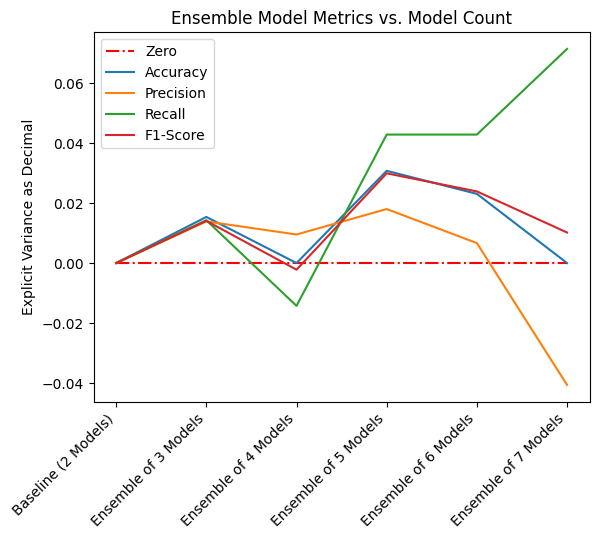

In [152]:
plot_headers = [f"Ensemble of {x} Models" for x in range(3, len(ensemble_metrics)+2)]
plot_headers.insert(0, "Baseline (2 Models)")
cumulative_difference_2model = []
for i in ensemble_metrics[1:]:
    cumulative_difference_2model.append([k - j for k, j in zip(i, ensemble_metrics[0])])
#print(plot_headers)
#print(cumulative_difference_2model)
Acc = [i[0] for i in cumulative_difference_2model]
Acc.insert(0, 0)
Prec = [i[1] for i in cumulative_difference_2model]
Prec.insert(0, 0)
Rec = [i[2] for i in cumulative_difference_2model]
Rec.insert(0, 0)
F1 = [i[3] for i in cumulative_difference_2model]
F1.insert(0, 0)
Range = range(len(cumulative_difference_2model)+1)
plt.plot([0, len(cumulative_difference_2model)], [0, 0], color= "red", linestyle= "-.", label = "Zero")
plt.plot(Range, Acc, label= "Accuracy")
plt.plot(Range, Prec, label= "Precision")
plt.plot(Range, Rec, label= "Recall")
plt.plot(Range, F1, label= "F1-Score")
plt.xticks(Range, plot_headers, rotation=45, ha="right")
plt.title("Ensemble Model Metrics vs. Model Count")
plt.legend()
plt.ylabel("Explicit Variance as Decimal")
plt.savefig("Plots\\Ensemble_Model_Metrics_Comparison.png", dpi=150, bbox_inches="tight")

[0.823076923076923, 0.8133333333333334, 0.8714285714285714, 0.8413793103448276] 
 [0.8615384615384616, 0.8611111111111112, 0.8857142857142857, 0.8732394366197183]


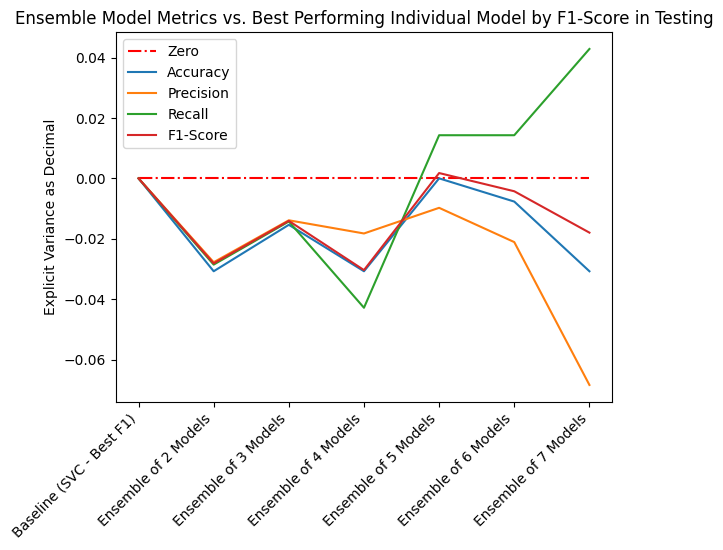

In [153]:
# XGBoost - Best ROC_AUC
#print(test_metrics_single_model[4])
best_roc = test_metrics_single_model[4]
# Model with best F1-Score
best_idx = max(range(len(test_metrics_single_model)), key=lambda i: test_metrics_single_model[i][0])
#print(model_names[best_idx], test_metrics_single_model[best_idx])
best_f1 = test_metrics_single_model[best_idx]
print(best_roc, "\n", best_f1)


plot_headers = [f"Ensemble of {x} Models" for x in range(2, len(ensemble_metrics)+2)]
plot_headers.insert(0, "Baseline (SVC - Best F1)")
cumulative_difference_2model = []
for i in ensemble_metrics:
    cumulative_difference_2model.append([k - j for k, j in zip(i, best_f1)])
#print(plot_headers)
#print(cumulative_difference_2model)
Acc = [i[0] for i in cumulative_difference_2model]
Acc.insert(0, 0)
Prec = [i[1] for i in cumulative_difference_2model]
Prec.insert(0, 0)
Rec = [i[2] for i in cumulative_difference_2model]
Rec.insert(0, 0)
F1 = [i[3] for i in cumulative_difference_2model]
F1.insert(0, 0)
Range = range(len(cumulative_difference_2model)+1)
plt.plot([0, len(cumulative_difference_2model)], [0, 0], color= "red", linestyle= "-.", label = "Zero")
plt.plot(Range, Acc, label= "Accuracy")
plt.plot(Range, Prec, label= "Precision")
plt.plot(Range, Rec, label= "Recall")
plt.plot(Range, F1, label= "F1-Score")
plt.xticks(Range, plot_headers, rotation=45, ha="right")
plt.title("Ensemble Model Metrics vs. Best Performing Individual Model by F1-Score in Testing")
plt.legend()
plt.ylabel("Explicit Variance as Decimal")
plt.savefig("Plots\\Ensemble_Model_Metrics_Comparison_BestF1.png", dpi=150, bbox_inches="tight")


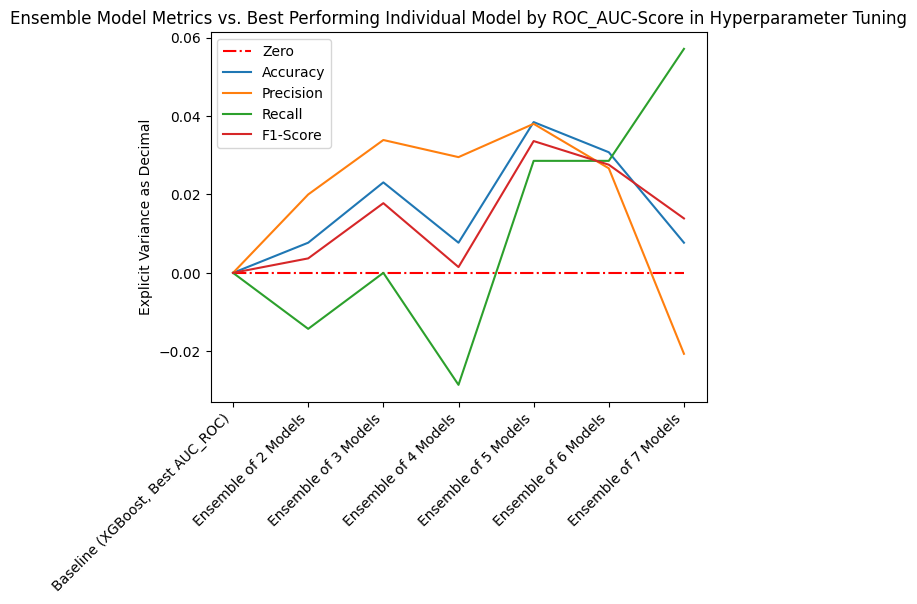

In [154]:
plot_headers[0] = "Baseline (XGBoost, Best AUC_ROC)"
cumulative_difference_2model = []
for i in ensemble_metrics:
    cumulative_difference_2model.append([k - j for k, j in zip(i, best_roc)])
#print(plot_headers)
#print(cumulative_difference_2model)
Acc = [i[0] for i in cumulative_difference_2model]
Acc.insert(0, 0)
Prec = [i[1] for i in cumulative_difference_2model]
Prec.insert(0, 0)
Rec = [i[2] for i in cumulative_difference_2model]
Rec.insert(0, 0)
F1 = [i[3] for i in cumulative_difference_2model]
F1.insert(0, 0)
Range = range(len(cumulative_difference_2model)+1)
plt.plot([0, len(cumulative_difference_2model)], [0, 0], color= "red", linestyle= "-.", label = "Zero")
plt.plot(Range, Acc, label= "Accuracy")
plt.plot(Range, Prec, label= "Precision")
plt.plot(Range, Rec, label= "Recall")
plt.plot(Range, F1, label= "F1-Score")
plt.xticks(Range, plot_headers, rotation=45, ha="right")
plt.title("Ensemble Model Metrics vs. Best Performing Individual Model by ROC_AUC-Score in Hyperparameter Tuning")
plt.legend()
plt.ylabel("Explicit Variance as Decimal")
plt.savefig("Plots\\Ensemble_Model_Metrics_Comparison_BestROCAUC.png", dpi=150, bbox_inches="tight")


In [155]:
# Comparison of model "agreement" -> lower is better for ensemble. If best models agree all/most of the time, they are not good for ensemble.
preds = {
    name: predict_with_threshold(model, splits[2], thresholds[name])
    for name, model in zip(model_names, tuned_models)
}

output_path = "Texts\\Model_Agreement.txt"

with open(output_path, "w") as f:
    for name1 in model_names:
        for name2 in model_names:
            if name1 < name2:   # keep your alphabetical/ordered comparison
                agreement = (preds[name1] == preds[name2]).mean()
                line = f"{name1} vs {name2}: {agreement:.3f} agreement\n"
                f.write(line)

C:\Users\Fearg\anaconda3\envs\DCU\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
